In [1]:
!pip3 install seaborn

사용 가능한 한글/한글 가능 후보 폰트:
['Apple SD Gothic Neo', 'AppleGothic', 'Nanum Brush Script', 'Nanum Gothic', 'Nanum Myeongjo']

선택된 폰트: Apple SD Gothic Neo


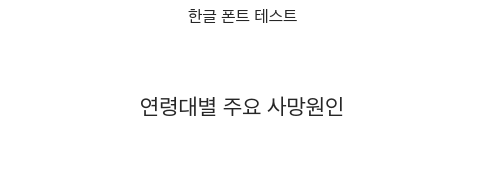

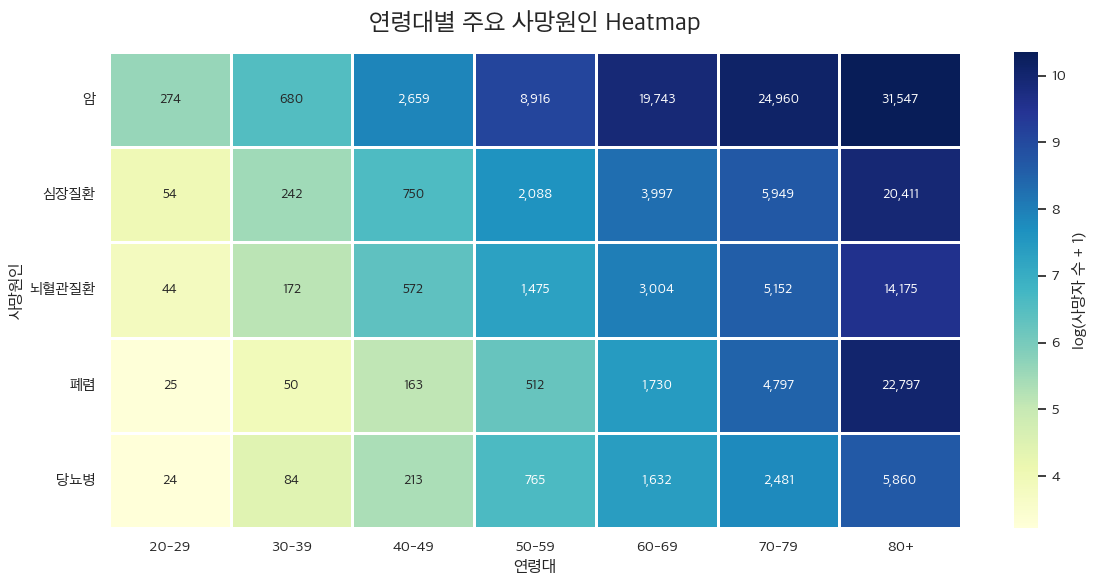

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns

font_names = sorted(set(f.name for f in fm.fontManager.ttflist))

korean_candidates = [
    name for name in font_names
    if any(keyword in name for keyword in [
        'Apple SD Gothic Neo', 'AppleGothic',
        'Nanum', 'Malgun', 'Batang', 'Gulim', 'Dotum'
    ])
]

print("사용 가능한 한글/한글 가능 후보 폰트:")
print(korean_candidates)


if 'Apple SD Gothic Neo' in korean_candidates:
    selected_font = 'Apple SD Gothic Neo'
elif 'AppleGothic' in korean_candidates:
    selected_font = 'AppleGothic'
elif any('Nanum' in f for f in korean_candidates):
    selected_font = [f for f in korean_candidates if 'Nanum' in f][0]
else:
    selected_font = None

print("\n선택된 폰트:", selected_font)


if selected_font is not None:
    mpl.rcParams['font.family'] = selected_font
    plt.rcParams['font.family'] = selected_font
    sns.set_theme(style="white", font=selected_font)
else:
    print("\n⚠️ 한글 폰트를 못 찾음. 아래 '폰트 설치 방법' 참고.")

mpl.rcParams['axes.unicode_minus'] = False


plt.figure(figsize=(6, 2))
plt.title("한글 폰트 테스트")
plt.text(0.5, 0.5, "연령대별 주요 사망원인", ha='center', va='center', fontsize=16)
plt.axis('off')
plt.show()


data = {
    '연령대': ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+'],
    '암': [274, 680, 2659, 8916, 19743, 24960, 31547],
    '심장질환': [54, 242, 750, 2088, 3997, 5949, 20411],
    '뇌혈관질환': [44, 172, 572, 1475, 3004, 5152, 14175],
    '폐렴': [25, 50, 163, 512, 1730, 4797, 22797],
    '당뇨병': [24, 84, 213, 765, 1632, 2481, 5860]
}

df = pd.DataFrame(data)
df.set_index('연령대', inplace=True)
df_t = df.T
df_log = np.log1p(df_t)


plt.figure(figsize=(12, 6))

ax = sns.heatmap(
    df_log,
    annot=df_t,
    fmt=',',
    cmap='YlGnBu',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'log(사망자 수 + 1)'},
    annot_kws={'size': 10, 'weight': 'bold'}
)

plt.title('연령대별 주요 사망원인 Heatmap', fontsize=18, weight='bold', pad=15)
plt.xlabel('연령대', fontsize=12, weight='bold')
plt.ylabel('사망원인', fontsize=12, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


=== 연령_index와 질병별 상관계수 ===
암: 0.968
심장질환: 0.809
뇌혈관질환: 0.838
폐렴: 0.735
당뇨병: 0.874


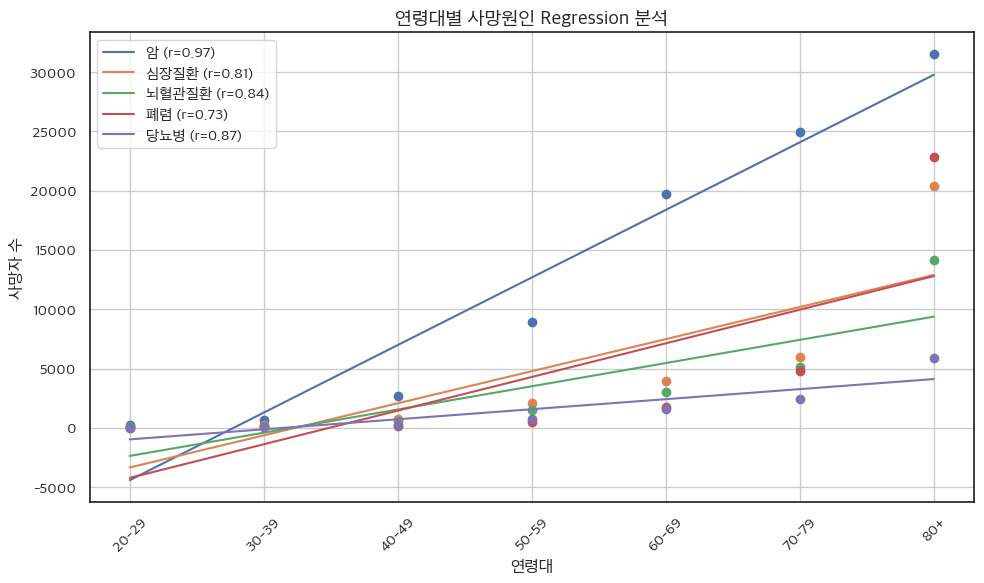

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = {
    '연령대': ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+'],
    '연령_index': [1, 2, 3, 4, 5, 6, 7],
    '암': [274, 680, 2659, 8916, 19743, 24960, 31547],
    '심장질환': [54, 242, 750, 2088, 3997, 5949, 20411],
    '뇌혈관질환': [44, 172, 572, 1475, 3004, 5152, 14175],
    '폐렴': [25, 50, 163, 512, 1730, 4797, 22797],
    '당뇨병': [24, 84, 213, 765, 1632, 2481, 5860]
}

df = pd.DataFrame(data)


disease_cols = ['암', '심장질환', '뇌혈관질환', '폐렴', '당뇨병']

print("\n=== 연령_index와 질병별 상관계수 ===")
for col in disease_cols:
    r = df['연령_index'].corr(df[col])
    print(f"{col}: {r:.3f}")


plt.figure(figsize=(10, 6))

x = df['연령_index']
x_labels = df['연령대']

for col in disease_cols:
    y = df[col]
    
    # 회귀선 계산
    coef = np.polyfit(x, y, 1)
    poly = np.poly1d(coef)
    
    # 상관계수
    r = x.corr(y)
    
    # scatter
    plt.scatter(x, y)
    
    # regression line
    plt.plot(x, poly(x), label=f"{col} (r={r:.2f})")


plt.title('연령대별 사망원인 Regression 분석', fontsize=14)
plt.xlabel('연령대')
plt.ylabel('사망자 수')

plt.xticks(x, x_labels, rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()